# Lab 1

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_iris

## Tasks (Version 5) - predicting class with Linear Regression

### 1. Fit the target using Linear Regression

#### Loading data

In [2]:
iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [3]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['class'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [4]:
X = df[iris.feature_names]
y = df['class']
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [5]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: class, Length: 150, dtype: int64

#### Training

In [6]:
def check_different_test_ratios(X, y, title):
    lr = LinearRegression()

    train_sizes=[0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
    cur_train_size, train_scores, test_scores = learning_curve(lr, X, y, train_sizes=train_sizes)

    mean_train_scores, mean_test_scores = [], []
    for train_size, cv_train_scores, cv_test_scores in zip(train_sizes, train_scores, test_scores):
        print(f"{train_size} training split:")
        mean_train_scores.append(cv_train_scores.mean())
        mean_test_scores.append(cv_test_scores.mean())
        print(f"Avg train accuracy = {cv_train_scores.mean():.2f}")
        print(f"Avg test accuracy = {cv_test_scores.mean():.2f}")

    _, ax = plt.subplots()
    ax.set(xlabel='Training set fraction', ylabel='Accuracy', title=title)
    ax.plot(train_sizes, mean_train_scores, label='Training accuracy')
    ax.plot(train_sizes, mean_test_scores, label='Validation accuracy')
    ax.grid()
    ax.legend()
    plt.show()

0.5 training split:
Avg train accuracy = 0.96
Avg test accuracy = 0.17
0.6 training split:
Avg train accuracy = 0.96
Avg test accuracy = 0.17
0.7 training split:
Avg train accuracy = 0.94
Avg test accuracy = 0.15
0.8 training split:
Avg train accuracy = 0.94
Avg test accuracy = 0.27
0.9 training split:
Avg train accuracy = 0.92
Avg test accuracy = 0.31
0.95 training split:
Avg train accuracy = 0.93
Avg test accuracy = 0.32


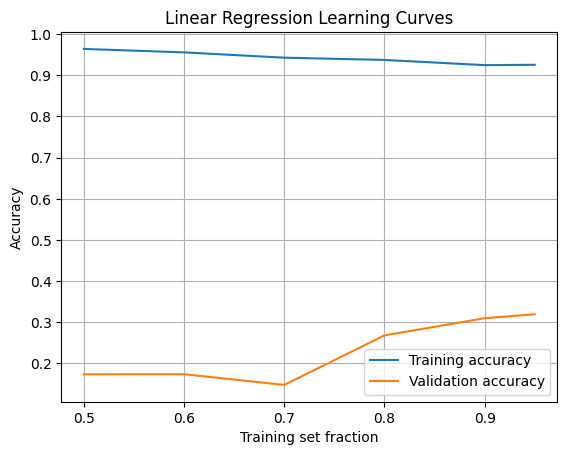

In [7]:
check_different_test_ratios(X, y, 'Linear Regression Learning Curves')

#### Investigating why the results are bad for Linear Regression

In [8]:
def plot_preds_vs_petal_length(X, y, X_test_index, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    lr = LinearRegression()
    y_preds = lr.fit(X_train, y_train).predict(X_test)

    _, ax = plt.subplots()
    ax.set(xlabel='Petal length, cm', ylabel='Class',
           title=title)
    if isinstance(X_test_index, str):
        ax.scatter(X_test[X_test_index], y_test, label='Real values')
        ax.scatter(X_test[X_test_index], y_preds, label='Predicted values')
    else:
        ax.scatter(X_test[:, X_test_index], y_test, label='Real values')
        ax.scatter(X_test[:, X_test_index], y_preds, label='Predicted values')
    ax.grid()
    ax.legend()
    plt.show()

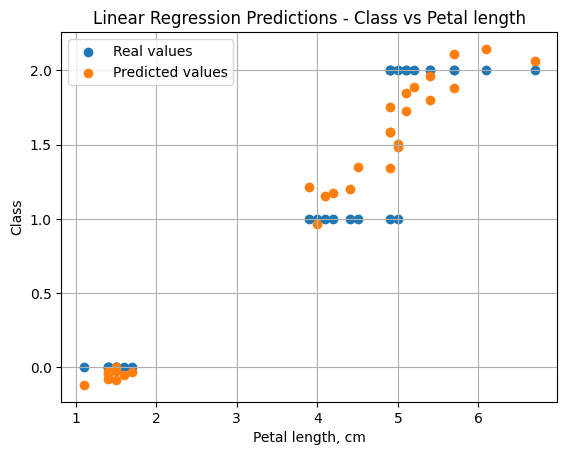

In [9]:
plot_preds_vs_petal_length(X, y, 'petal length (cm)', 'Linear Regression Predictions - Class vs Petal length')

### 2. Fit the target using Polynomial Regression

In [10]:
from sklearn.preprocessing import PolynomialFeatures

#### Create polynomial features and scale them

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_poly = PolynomialFeatures(degree=2, interaction_only=False)
X_poly = X_poly.fit_transform(X_scaled)
X_poly

array([[ 1.        , -0.90068117,  1.01900435, ...,  1.79620714,
         1.76299334,  1.73039369],
       [ 1.        , -1.14301691, -0.13197948, ...,  1.79620714,
         1.76299334,  1.73039369],
       [ 1.        , -1.38535265,  0.32841405, ...,  1.95178769,
         1.83775981,  1.73039369],
       ...,
       [ 1.        ,  0.79566902, -0.13197948, ...,  0.67173711,
         0.86380061,  1.11077903],
       [ 1.        ,  0.4321654 ,  0.78880759, ...,  0.87099392,
         1.35215184,  2.09911293],
       [ 1.        ,  0.06866179, -0.13197948, ...,  0.58180018,
         0.60309058,  0.62516008]], shape=(150, 15))

In [13]:
y = df['class']

0.5 training split:
Avg train accuracy = 0.99
Avg test accuracy = 0.28
0.6 training split:
Avg train accuracy = 0.98
Avg test accuracy = 0.15
0.7 training split:
Avg train accuracy = 0.97
Avg test accuracy = -0.14
0.8 training split:
Avg train accuracy = 0.96
Avg test accuracy = 0.30
0.9 training split:
Avg train accuracy = 0.95
Avg test accuracy = 0.32
0.95 training split:
Avg train accuracy = 0.95
Avg test accuracy = 0.33


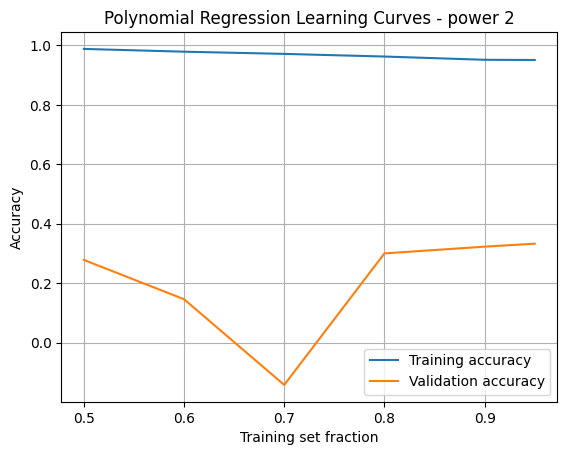

In [14]:
check_different_test_ratios(X_poly, y, 'Polynomial Regression Learning Curves - power 2')

#### Increase the polynomial power

In [16]:
X_poly = PolynomialFeatures(degree=3, interaction_only=False)
X_poly = X_poly.fit_transform(X_scaled)
X_poly

array([[ 1.        , -0.90068117,  1.01900435, ..., -2.36281044,
        -2.31911953, -2.27623651],
       [ 1.        , -1.14301691, -0.13197948, ..., -2.36281044,
        -2.31911953, -2.27623651],
       [ 1.        , -1.38535265,  0.32841405, ..., -2.56746798,
        -2.41747065, -2.27623651],
       ...,
       [ 1.        ,  0.79566902, -0.13197948, ...,  0.70796726,
         0.91038971,  1.17068892],
       [ 1.        ,  0.4321654 ,  0.78880759, ...,  1.26192349,
         1.95904028,  3.0412611 ],
       [ 1.        ,  0.06866179, -0.13197948, ...,  0.46001233,
         0.47684602,  0.49429573]], shape=(150, 35))

In [17]:
y = df['class']

0.5 training split:
Avg train accuracy = 1.00
Avg test accuracy = -0.76
0.6 training split:
Avg train accuracy = 1.00
Avg test accuracy = -1.75
0.7 training split:
Avg train accuracy = 0.99
Avg test accuracy = -0.86
0.8 training split:
Avg train accuracy = 0.98
Avg test accuracy = -0.34
0.9 training split:
Avg train accuracy = 0.97
Avg test accuracy = -0.12
0.95 training split:
Avg train accuracy = 0.97
Avg test accuracy = 0.20


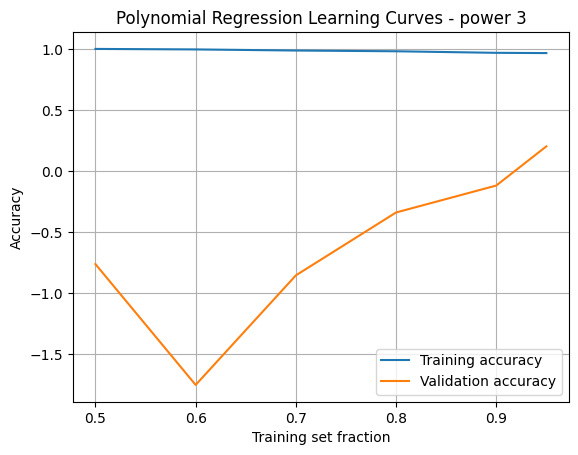

In [18]:
check_different_test_ratios(X_poly, y, 'Polynomial Regression Learning Curves - power 3')

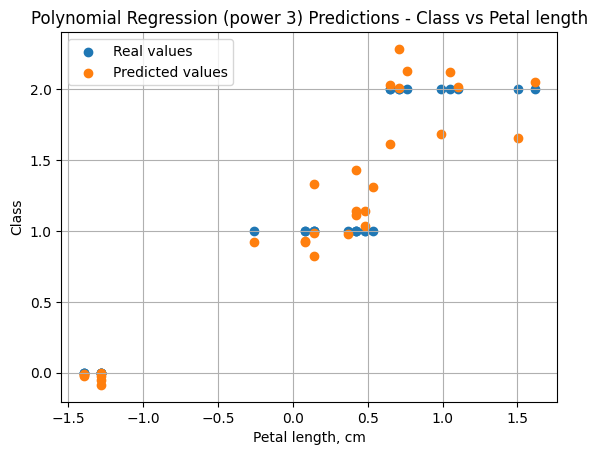

In [19]:
plot_preds_vs_petal_length(X_poly, y, 3, 'Polynomial Regression (power 3) Predictions - Class vs Petal length')

#### Calculating MSE, RMSE, MAE, R<sup>2</sup>

In [20]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

In [21]:
def calc_scores(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    lr = LinearRegression()
    y_preds = lr.fit(X_train, y_train).predict(X_test)

    print(f"MSE: {mean_squared_error(y_test, y_preds)}")
    print(f"RMSE: {root_mean_squared_error(y_test, y_preds)}")
    print(f"MAE: {mean_absolute_error(y_test, y_preds)}")
    print(f"R^2: {r2_score(y_test, y_preds)}")

In [22]:
calc_scores(X_poly, y)

MSE: 0.05158329520111931
RMSE: 0.22711956146734547
MAE: 0.1580447618743336
R^2: 0.8992950852906564


#### Plot learning curves for MSE, RMSE, MAE, R<sup>2</sup>

In [23]:
def plot_learning_curves(X, y, title):
    lr = LinearRegression()

    train_sizes=[0.5, 0.6, 0.7, 0.8, 0.9, 0.95]

    mse, rmse, mae, mape, r2 = [], [], [], [], []
    for train_size in train_sizes:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1-train_size)
        lr = LinearRegression()
        y_preds = lr.fit(X_train, y_train).predict(X_test)
        print(f"{train_size} training split:")
        mse.append(mean_squared_error(y_test, y_preds))
        rmse.append(root_mean_squared_error(y_test, y_preds))
        mae.append(mean_absolute_error(y_test, y_preds))
        mape.append(mean_absolute_percentage_error(y_test, y_preds))
        r2.append(r2_score(y_test, y_preds))
        print(f"Test MSE = {mse[-1]:.2f}")
        print(f"Test RMSE = {rmse[-1]:.2f}")
        print(f"Test MAE = {mae[-1]:.2f}")
        print(f"Test MAPE = {mape[-1]:.2f}")
        print(f"Test R^2 = {r2[-1]:.2f}")

    _, ax = plt.subplots()
    ax.set(xlabel='Training set fraction', ylabel='Validation loss', title=title)
    ax.plot(train_sizes, mse, label='MSE')
    ax.plot(train_sizes, rmse, label='RMSE')
    ax.plot(train_sizes, mae, label='MAE')
    ax.plot(train_sizes, r2, label='R^2')
    ax.grid()
    ax.legend()
    plt.show()

0.5 training split:
Test MSE = 0.07
Test RMSE = 0.26
Test MAE = 0.18
Test MAPE = 166893067523826.22
Test R^2 = 0.91
0.6 training split:
Test MSE = 0.09
Test RMSE = 0.29
Test MAE = 0.20
Test MAPE = 184822090784700.06
Test R^2 = 0.87
0.7 training split:
Test MSE = 0.06
Test RMSE = 0.24
Test MAE = 0.18
Test MAPE = 87988048069349.06
Test R^2 = 0.91
0.8 training split:
Test MSE = 0.06
Test RMSE = 0.25
Test MAE = 0.17
Test MAPE = 137015679328649.59
Test R^2 = 0.90
0.9 training split:
Test MSE = 0.06
Test RMSE = 0.24
Test MAE = 0.17
Test MAPE = 72733124400776.55
Test R^2 = 0.94
0.95 training split:
Test MSE = 0.02
Test RMSE = 0.13
Test MAE = 0.11
Test MAPE = 188798812106980.06
Test R^2 = 0.97


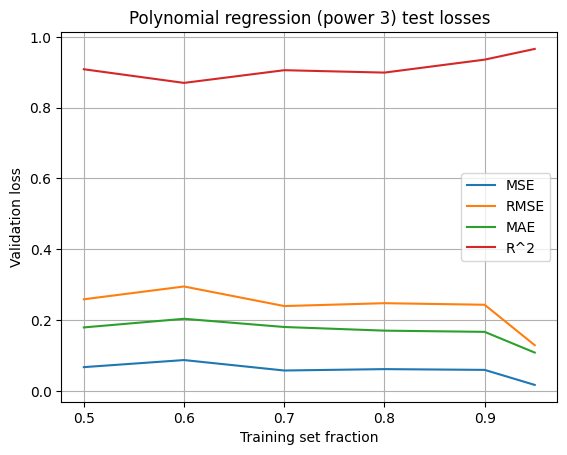

In [24]:
plot_learning_curves(X_poly, y, 'Polynomial regression (power 3) test losses')

## Tasks (Version 5) - predicting one of the other variables (Sepal length) with Linear Regression

### 1. Fit the target using Linear Regression

#### Loading data

In [25]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['class'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


#### One-hot encoding the class variable

In [26]:
df = pd.get_dummies(df, columns=['class'], prefix='class')
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class_0,class_1,class_2
0,5.1,3.5,1.4,0.2,True,False,False
1,4.9,3.0,1.4,0.2,True,False,False
2,4.7,3.2,1.3,0.2,True,False,False
3,4.6,3.1,1.5,0.2,True,False,False
4,5.0,3.6,1.4,0.2,True,False,False
...,...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,False,False,True
146,6.3,2.5,5.0,1.9,False,False,True
147,6.5,3.0,5.2,2.0,False,False,True
148,6.2,3.4,5.4,2.3,False,False,True


In [27]:
feature_names = [i for i in iris.feature_names if 'sepal length' not in i]
feature_names.extend(['class_0', 'class_1', 'class_2'])
X = df[feature_names]
y = df['sepal length (cm)']
X

,sepal width (cm),petal length (cm),petal width (cm),class_0,class_1,class_2
0,3.5,1.4,0.2,True,False,False
1,3.0,1.4,0.2,True,False,False
2,3.2,1.3,0.2,True,False,False
3,3.1,1.5,0.2,True,False,False
4,3.6,1.4,0.2,True,False,False
...,...,...,...,...,...,...
145,3.0,5.2,2.3,False,False,True
146,2.5,5.0,1.9,False,False,True
147,3.0,5.2,2.0,False,False,True
148,3.4,5.4,2.3,False,False,True


In [28]:
y

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal length (cm), Length: 150, dtype: float64

#### Training

0.5 training split:
Avg train accuracy = 0.80
Avg test accuracy = 0.10
0.6 training split:
Avg train accuracy = 0.79
Avg test accuracy = 0.53
0.7 training split:
Avg train accuracy = 0.84
Avg test accuracy = 0.56
0.8 training split:
Avg train accuracy = 0.85
Avg test accuracy = 0.57
0.9 training split:
Avg train accuracy = 0.86
Avg test accuracy = 0.55
0.95 training split:
Avg train accuracy = 0.86
Avg test accuracy = 0.59


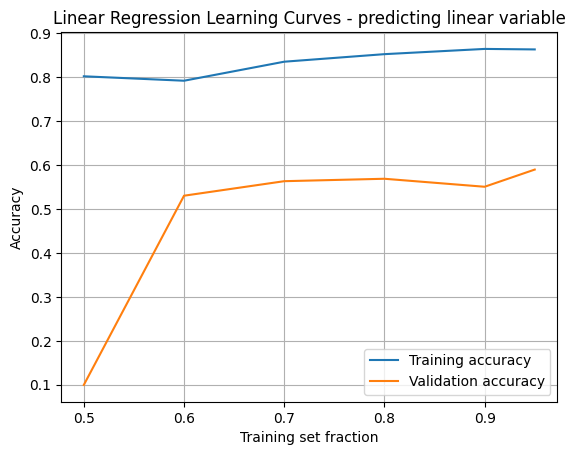

In [29]:
check_different_test_ratios(X, y, 'Linear Regression Learning Curves - predicting linear variable')

#### Investigating why the results are bad for Linear Regression

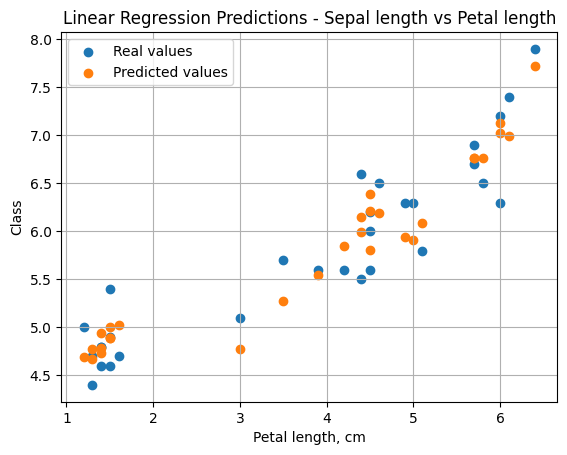

In [30]:
plot_preds_vs_petal_length(X, y, 'petal length (cm)', 'Linear Regression Predictions - Sepal length vs Petal length')

### 2. Fit the target using Polynomial Regression

#### Create polynomial features and scale them

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

poly = PolynomialFeatures(degree=2, interaction_only=False)
X_poly = poly.fit_transform(X_scaled)
X_poly

array([[ 1.        ,  1.01900435, -1.34022653, ...,  0.5       ,
         0.5       ,  0.5       ],
       [ 1.        , -0.13197948, -1.34022653, ...,  0.5       ,
         0.5       ,  0.5       ],
       [ 1.        ,  0.32841405, -1.39706395, ...,  0.5       ,
         0.5       ,  0.5       ],
       ...,
       [ 1.        , -0.13197948,  0.8195957 , ...,  0.5       ,
        -1.        ,  2.        ],
       [ 1.        ,  0.78880759,  0.93327055, ...,  0.5       ,
        -1.        ,  2.        ],
       [ 1.        , -0.13197948,  0.76275827, ...,  0.5       ,
        -1.        ,  2.        ]], shape=(150, 28))

In [32]:
y = df['sepal length (cm)']

0.5 training split:
Avg train accuracy = 0.85
Avg test accuracy = -1.11
0.6 training split:
Avg train accuracy = 0.83
Avg test accuracy = -0.60
0.7 training split:
Avg train accuracy = 0.87
Avg test accuracy = -2.58
0.8 training split:
Avg train accuracy = 0.88
Avg test accuracy = -0.50
0.9 training split:
Avg train accuracy = 0.89
Avg test accuracy = 0.37
0.95 training split:
Avg train accuracy = 0.89
Avg test accuracy = 0.52


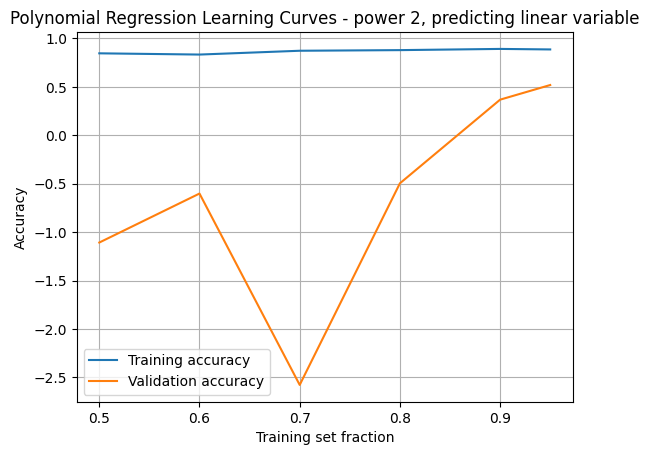

In [33]:
check_different_test_ratios(X_poly, y, 'Polynomial Regression Learning Curves - power 2, predicting linear variable')

#### Increase the polynomial power

In [34]:
X_poly = PolynomialFeatures(degree=3, interaction_only=False)
X_poly = poly.fit_transform(X_scaled)
X_poly

array([[ 1.        ,  1.01900435, -1.34022653, ...,  0.5       ,
         0.5       ,  0.5       ],
       [ 1.        , -0.13197948, -1.34022653, ...,  0.5       ,
         0.5       ,  0.5       ],
       [ 1.        ,  0.32841405, -1.39706395, ...,  0.5       ,
         0.5       ,  0.5       ],
       ...,
       [ 1.        , -0.13197948,  0.8195957 , ...,  0.5       ,
        -1.        ,  2.        ],
       [ 1.        ,  0.78880759,  0.93327055, ...,  0.5       ,
        -1.        ,  2.        ],
       [ 1.        , -0.13197948,  0.76275827, ...,  0.5       ,
        -1.        ,  2.        ]], shape=(150, 28))

0.5 training split:
Avg train accuracy = 0.85
Avg test accuracy = -1.11
0.6 training split:
Avg train accuracy = 0.83
Avg test accuracy = -0.60
0.7 training split:
Avg train accuracy = 0.87
Avg test accuracy = -2.58
0.8 training split:
Avg train accuracy = 0.88
Avg test accuracy = -0.50
0.9 training split:
Avg train accuracy = 0.89
Avg test accuracy = 0.37
0.95 training split:
Avg train accuracy = 0.89
Avg test accuracy = 0.52


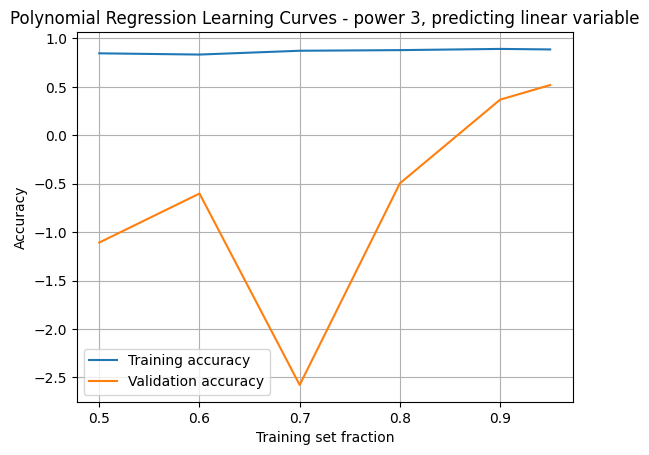

In [37]:
check_different_test_ratios(X_poly, y, 'Polynomial Regression Learning Curves - power 3, predicting linear variable')

In [39]:
X_poly = PolynomialFeatures(degree=2, interaction_only=False)
X_poly = poly.fit_transform(X_scaled)
X_poly

array([[ 1.        ,  1.01900435, -1.34022653, ...,  0.5       ,
         0.5       ,  0.5       ],
       [ 1.        , -0.13197948, -1.34022653, ...,  0.5       ,
         0.5       ,  0.5       ],
       [ 1.        ,  0.32841405, -1.39706395, ...,  0.5       ,
         0.5       ,  0.5       ],
       ...,
       [ 1.        , -0.13197948,  0.8195957 , ...,  0.5       ,
        -1.        ,  2.        ],
       [ 1.        ,  0.78880759,  0.93327055, ...,  0.5       ,
        -1.        ,  2.        ],
       [ 1.        , -0.13197948,  0.76275827, ...,  0.5       ,
        -1.        ,  2.        ]], shape=(150, 28))

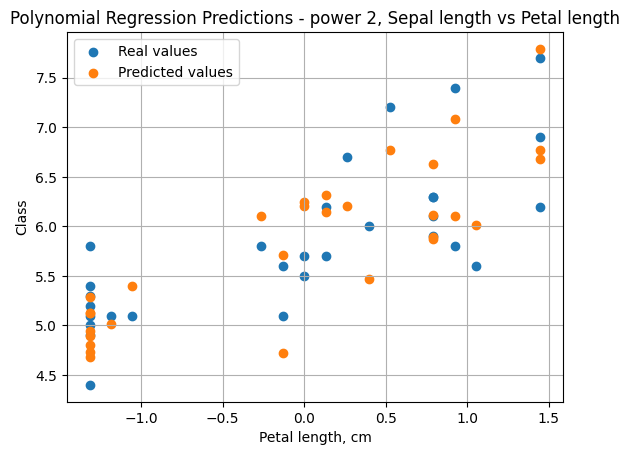

In [40]:
plot_preds_vs_petal_length(X_poly, y, 3, 'Polynomial Regression Predictions - power 2, Sepal length vs Petal length')

#### Calculating MSE, RMSE, MAE, R<sup>2</sup>

In [41]:
calc_scores(X_poly, y)

MSE: 0.1669622847860496
RMSE: 0.40861018683587613
MAE: 0.33723405663711786
R^2: 0.6958731075159493


#### Plot learning curves for MSE, RMSE, MAE, R<sup>2</sup>

0.5 training split:
Test MSE = 0.09
Test RMSE = 0.30
Test MAE = 0.25
Test MAPE = 0.04
Test R^2 = 0.88
0.6 training split:
Test MSE = 0.09
Test RMSE = 0.31
Test MAE = 0.26
Test MAPE = 0.05
Test R^2 = 0.88
0.7 training split:
Test MSE = 0.13
Test RMSE = 0.36
Test MAE = 0.29
Test MAPE = 0.05
Test R^2 = 0.84
0.8 training split:
Test MSE = 0.10
Test RMSE = 0.32
Test MAE = 0.29
Test MAPE = 0.05
Test R^2 = 0.84
0.9 training split:
Test MSE = 0.12
Test RMSE = 0.35
Test MAE = 0.28
Test MAPE = 0.04
Test R^2 = 0.80
0.95 training split:
Test MSE = 0.11
Test RMSE = 0.33
Test MAE = 0.27
Test MAPE = 0.04
Test R^2 = 0.80


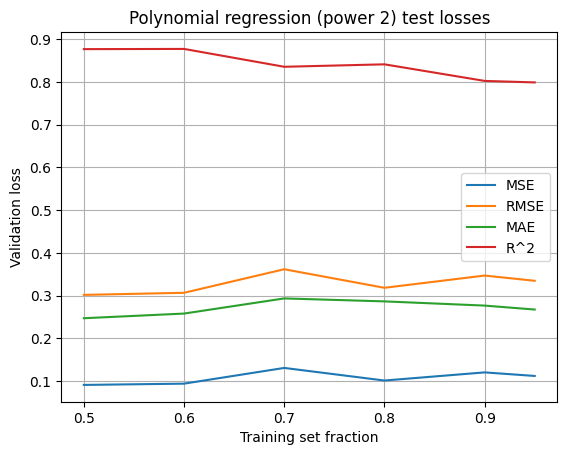

In [42]:
plot_learning_curves(X_poly, y, 'Polynomial regression (power 2) test losses')